# Make triangulation (asume cam -> world)

In [ ]:
import os
import json
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import cv2
from scipy.optimize import least_squares
from tqdm import tqdm


# ----------------------------- Config ---------------------------------
max_cameras = ['gopro8', 'gopro5', 'gopro6', 'gopro9', 'gopro12']
methods = ["vgba","vggt_ba","mast3r_ba","vggt","mgba"]
run = "run3"
cams = "3 cameras"
for method in methods:
    pose_outputs_dir = Path("pose_outputs/cha/synced_cut_long")
    intrinsics_dir   = Path("camera_poses/cha/camera_intrinsics")
    extrinsics_path  = Path(f"camera_poses/cha/camera_extrinsics/{cams}/{method}/poses_spp_surgeon_no_occlusion_run_3.json")
    # If your new file is named differently (e.g. camera_poses_vgba.json), just point extrinsics_path to it.

    output_dir = Path("hand_triangulation_output")
    output_dir.mkdir(parents=True, exist_ok=True)

    SCORE_THRESH = 0.3
    HAND_JOINTS = 21
    HAND_KEYS = ["left_hand_instances", "right_hand_instances"]  # order preserved in outputs
    # ----------------------------------------------------------------------


    # ============================= I/O HELPERS =============================

    def load_intrinsics_for_camera(cam: str) -> Tuple[np.ndarray, np.ndarray]:
        """
        Load intrinsics and distortion for a camera.
        Expects files named like '{cam}_synced_intrinsics.json' in intrinsics_dir.
        Returns (K, dist) where K is 3x3, dist is (k1,k2,p1,p2,k3) as 1x5.
        """
        candidates = [
            intrinsics_dir / f"{cam}_synced_intrinsics.json",
        ]
        for fp in candidates:
            if fp.exists():
                with open(fp, "r") as f:
                    intr = json.load(f)
                # Expected structure (OpenCV style in your provided file)
                k = np.array(intr["sensors"]["RGB"]["intrinsics"]["data"], dtype=float).reshape(3, 3)
                dist = np.array(intr["sensors"]["RGB"]["distortionCoefficients"]["data"], dtype=float).reshape(-1)
                return k, dist
        raise FileNotFoundError(f"Intrinsics for {cam} not found. Tried: {candidates}")


    def _euler_ZYX_to_R(euler_deg: List[float]) -> np.ndarray:
        """
        ZYX (yaw, pitch, roll) in DEGREES -> rotation matrix.
        Convention: R = Rz * Ry * Rx
        """
        z, y, x = np.deg2rad(euler_deg)
        cz, sz = np.cos(z), np.sin(z)
        cy, sy = np.cos(y), np.sin(y)
        cx, sx = np.cos(x), np.sin(x)

        Rz = np.array([[ cz, -sz, 0.0],
                    [ sz,  cz, 0.0],
                    [0.0, 0.0, 1.0]])
        Ry = np.array([[ cy, 0.0,  sy],
                    [0.0, 1.0, 0.0],
                    [-sy, 0.0,  cy]])
        Rx = np.array([[1.0, 0.0,  0.0],
                    [0.0,  cx, -sx],
                    [0.0,  sx,  cx]])
        return Rz @ Ry @ Rx


    def load_extrinsics_only_ZYX_t(extr_path: Path) -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
        """
        STRICT loader for extrinsics in this exact per-camera format:

        "gopro12": {
            "euler_ZYX": [degZ, degY, degX],
            "t": [-1.641, 2.016, -1.085]
        }

        These are **camera poses** (camera->world). We convert to world->camera:
        R_wc = R_cw.T
        t_wc = -R_wc @ t_cw

        Returns: {cam: (R_wc, t_wc)}
        """
        with open(extr_path, "r") as f:
            data = json.load(f)

        # Validate format & collect
        out: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}
        for cam in max_cameras:
            block = data.get(cam)
            if not isinstance(block, dict) or "euler_ZYX" not in block or "t" not in block:
                # Fail hard if anything doesn't match the required format
                raise ValueError(
                    f"Extrinsics file must contain per-camera blocks with 'euler_ZYX' and 't'. "
                    f"Missing or invalid for '{cam}'."
                )
            R_cw = _euler_ZYX_to_R(block["euler_ZYX"])
            t_cw = np.array(block["t"], dtype=float).reshape(3,)
            R_wc = R_cw.T
            t_wc = -R_wc @ t_cw
            out[cam] = (R_wc, t_wc)

        return out


    def load_pose_json(path: Path) -> Dict:
        with open(path, "r") as f:
            return json.load(f)


    def frames_to_maps(instances: List[Dict]) -> Dict[int, Dict]:
        """
        Convert list of frames [{'frame_id': int, 'instances':[...]}] to map
        frame_id -> instance dict (first instance only).
        If no instances present in a given frame entry, this maps to None.
        """
        out = {}
        for item in instances:
            fid = int(item.get("frame_id", -1))
            insts = item.get("instances", [])
            out[fid] = insts[0] if (isinstance(insts, list) and len(insts) > 0) else None
        return out


    def gather_camera_streams() -> Dict[str, Dict[str, Dict[int, Dict]]]:
        """
        Returns:
        cams[cam_name][hand_key][frame_id] -> instance dict with 'keypoints' (21x2) and 'keypoint_scores'(21)
        Only includes cameras with available files.
        """
        cams = {}
        for cam in max_cameras:
            pose_file = pose_outputs_dir / f"{cam}_synced_cut_wholebody.json"
            if not pose_file.exists():
                # allow loose match if filename differs a bit
                alts = list(pose_outputs_dir.glob(f"{cam}*wholebody*.json"))
                if alts:
                    pose_file = alts[0]
            if not pose_file.exists():
                print(f"[WARN] Missing 2D detections for {cam}, skipping.")
                continue

            d = load_pose_json(pose_file)
            cam_dict = {}
            for hand_key in HAND_KEYS:
                if hand_key not in d:
                    print(f"[WARN] {hand_key} not found in {pose_file.name}, skipping this hand.")
                    continue
                cam_dict[hand_key] = frames_to_maps(d[hand_key])
            cams[cam] = cam_dict
        return cams


    # ============================= GEOMETRY ================================

    def undistort_points_to_pixel(uvs: np.ndarray, K: np.ndarray, dist: np.ndarray) -> np.ndarray:
        """
        Undistort pixel coordinates using OpenCV and return UNDISTORTED pixel coords (not normalized).
        cv2.undistortPoints with P=K returns pixel coordinates consistent with K.
        """
        if uvs.size == 0:
            return uvs
        pts = uvs.reshape(-1, 1, 2).astype(np.float32)
        undist = cv2.undistortPoints(pts, K, dist, P=K)  # -> (N,1,2) pixel coords
        return undist.reshape(-1, 2).astype(np.float64)


    def build_projection_matrix(K: np.ndarray, R: np.ndarray, t: np.ndarray) -> np.ndarray:
        """P = K [R | t]  with world->camera: x_cam = R X + t"""
        Rt = np.hstack([R, t.reshape(3, 1)])
        return K @ Rt


    def dlt_triangulate_multi(P_list: List[np.ndarray], xy_list: List[np.ndarray]) -> np.ndarray:
        """
        Linear n-view triangulation using DLT on UNDISTORTED pixel points.
        Returns 3D point (x,y,z) in world coords. NaNs if <2 views or ill-conditioned.
        """
        if len(P_list) < 2:
            return np.array([np.nan, np.nan, np.nan], dtype=float)

        A = []
        for P, (u, v) in zip(P_list, xy_list):
            A.append(u * P[2, :] - P[0, :])
            A.append(v * P[2, :] - P[1, :])
        A = np.asarray(A)

        try:
            _, _, Vt = np.linalg.svd(A)
            X = Vt[-1]
            if abs(X[3]) < 1e-9:
                return np.array([np.nan, np.nan, np.nan], dtype=float)
            X = X[:3] / X[3]
            return X
        except np.linalg.LinAlgError:
            return np.array([np.nan, np.nan, np.nan], dtype=float)


    def refine_triangulation(X_init: np.ndarray, P_list: List[np.ndarray], xy_list: List[np.ndarray]) -> np.ndarray:
        """
        Non-linear refinement of 3D point using Levenberg-Marquardt to minimize reprojection error.
        
        Args:
            X_init: Initial 3D point estimate from DLT (3,)
            P_list: List of projection matrices (each 3x4)
            xy_list: List of observed 2D points (each (2,))
        
        Returns:
            Refined 3D point (x,y,z) or original if optimization fails
        """
        if np.any(~np.isfinite(X_init)):
            return X_init
        
        def residuals(X):
            """Compute reprojection residuals for all views"""
            errs = []
            for P, xy_obs in zip(P_list, xy_list):
                # Project 3D point
                Xh = np.hstack([X, 1.0])
                x_proj = P @ Xh
                if abs(x_proj[2]) < 1e-9:
                    errs.extend([1e6, 1e6])  # large penalty for invalid projection
                else:
                    xy_proj = x_proj[:2] / x_proj[2]
                    errs.extend(xy_proj - xy_obs)
            return np.array(errs)
        
        try:
            result = least_squares(
                residuals,
                X_init,
                method='lm',  # Levenberg-Marquardt
                ftol=1e-6,
                xtol=1e-6,
                max_nfev=100
            )
            if result.success:
                return result.x
            else:
                return X_init
        except Exception:
            return X_init


    def project(P: np.ndarray, X: np.ndarray) -> np.ndarray:
        """Project 3D point with P (3x4) -> pixel (u,v)."""
        Xh = np.hstack([X, 1.0])
        x = P @ Xh
        if abs(x[2]) < 1e-9:
            return np.array([np.nan, np.nan], dtype=float)
        return (x[:2] / x[2]).astype(float)


    # ============================== MAIN ==================================
    extr = load_extrinsics_only_ZYX_t(extrinsics_path)

    # Load intrinsics for all cams; warn if missing
    intr = {}
    for cam in max_cameras:
        try:
            K, dist = load_intrinsics_for_camera(cam)
            intr[cam] = (K, dist)
        except FileNotFoundError as e:
            print(f"[WARN] {e}")

    # Load 2D streams
    cams = gather_camera_streams()
    available_cams = [c for c in max_cameras if c in cams and c in intr and c in extr]
    if len(available_cams) < 2:
        raise RuntimeError("Need at least two cameras with 2D data, intrinsics, and extrinsics.")

    # Frame range: union of frame_ids across available cams for the hands
    all_frame_ids = set()
    for cam in available_cams:
        for hand_key in HAND_KEYS:
            if hand_key in cams[cam]:
                all_frame_ids.update(cams[cam][hand_key].keys())
    if not all_frame_ids:
        raise RuntimeError("No frames found in the provided 2D files.")
    max_frame_id = max(all_frame_ids)
    num_frames = max_frame_id + 1

    # Prepare outputs
    hand_3d = [np.full((num_frames, HAND_JOINTS, 3), np.nan, dtype=float) for _ in HAND_KEYS]
    repro_err_px = [
        {cam: np.full((num_frames, HAND_JOINTS), np.nan, dtype=float) for cam in available_cams}
        for _ in HAND_KEYS
    ]

    # Precompute projection matrices
    P_mats = {}
    for cam in available_cams:
        K, _ = intr[cam]
        R, t = extr[cam]  # world->camera
        P_mats[cam] = build_projection_matrix(K, R, t)

    # Triangulate
    for fid in tqdm(range(num_frames), desc="Triangulating (DLT + refinement)"):
        for h_idx, hand_key in enumerate(HAND_KEYS):
            # Gather observations per joint
            per_joint_obs = {j: [] for j in range(HAND_JOINTS)}
            for cam in available_cams:
                fmap = cams[cam].get(hand_key, {})
                inst = fmap.get(fid, None)
                if not inst:
                    continue
                kps = np.asarray(inst.get("keypoints", []), dtype=float)  # (21,2)
                scs = np.asarray(inst.get("keypoint_scores", []), dtype=float)  # (21,)
                if kps.shape[0] != HAND_JOINTS or scs.shape[0] != HAND_JOINTS:
                    continue

                K, dist = intr[cam]
                undist_pixels = undistort_points_to_pixel(kps, K, dist)  # (21,2)
                for j in range(HAND_JOINTS):
                    if scs[j] > SCORE_THRESH and np.isfinite(undist_pixels[j]).all():
                        per_joint_obs[j].append((cam, P_mats[cam], undist_pixels[j], scs[j]))

            # Triangulate each joint
            for j in range(HAND_JOINTS):
                obs = per_joint_obs[j]
                if len(obs) < 2:
                    continue

                # sort by score desc
                obs.sort(key=lambda x: x[3], reverse=True)

                P_list = [o[1] for o in obs]
                xy_list = [o[2] for o in obs]
                
                # Step 1: DLT for initial estimate
                X_init = dlt_triangulate_multi(P_list, xy_list)
                
                # Step 2: Non-linear refinement
                X = refine_triangulation(X_init, P_list, xy_list)
                
                hand_3d[h_idx][fid, j, :] = X

                # Reprojection errors (px) for cameras used
                for (cam, P, uvd, _) in obs:
                    proj = project(P, X)  # pixel coords (consistent with K because we undistorted w/ P=K)
                    err = np.linalg.norm(proj - uvd)
                    repro_err_px[h_idx][cam][fid, j] = float(err)

    # Save outputs
    save_dir = (output_dir / method / run)
    save_dir.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        save_dir / "hands_3d_and_reproj_errors.npz",
        left_hand_3d=hand_3d[0],
        right_hand_3d=hand_3d[1],
        left_errors={cam: arr for cam, arr in repro_err_px[0].items()},
        right_errors={cam: arr for cam, arr in repro_err_px[1].items()},
        cameras=np.array(available_cams, dtype=object),
        score_threshold=SCORE_THRESH,
    )

    # CSV for quick inspection
    csv_path = save_dir / "reprojection_errors.csv"
    with open(csv_path, "w", newline="") as f:  # newline='' avoids extra blank lines on Windows
        f.write("hand,frame,joint,camera,error_px\n")
        for h_idx, hand_key in enumerate(HAND_KEYS):
            for cam in available_cams:
                err = repro_err_px[h_idx][cam]
                rows = np.argwhere(~np.isnan(err))
                for r in rows:
                    fr, j = int(r[0]), int(r[1])
                    f.write(f"{hand_key},{fr},{j},{cam},{err[fr, j]:.6f}\n")

    print(f"\nSaved:")
    print(f"- 3D hands + errors: {output_dir/method/'hands_3d_and_reproj_errors.npz'}")
    print(f"- Per-camera reprojection errors CSV: {csv_path}")



Triangulating (DLT + refinement): 100%|██████████| 1200/1200 [01:29<00:00, 13.42it/s]



Saved:
- 3D hands + errors: hand_triangulation_output\vgba\hands_3d_and_reproj_errors.npz
- Per-camera reprojection errors CSV: hand_triangulation_output\vgba\run3\reprojection_errors.csv


Triangulating (DLT + refinement): 100%|██████████| 1200/1200 [01:26<00:00, 13.89it/s]



Saved:
- 3D hands + errors: hand_triangulation_output\vggt_ba\hands_3d_and_reproj_errors.npz
- Per-camera reprojection errors CSV: hand_triangulation_output\vggt_ba\run3\reprojection_errors.csv


Triangulating (DLT + refinement): 100%|██████████| 1200/1200 [01:28<00:00, 13.60it/s]



Saved:
- 3D hands + errors: hand_triangulation_output\mast3r_ba\hands_3d_and_reproj_errors.npz
- Per-camera reprojection errors CSV: hand_triangulation_output\mast3r_ba\run3\reprojection_errors.csv


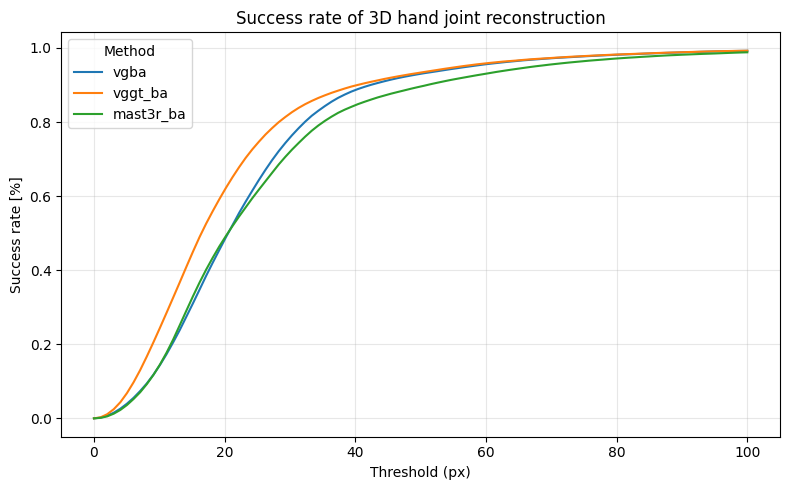

Saved combined CSV to: hand_triangulation_output\run3\success_rate_curves_combined.csv
Saved plot PNG to: hand_triangulation_output\success_rate_curves_combined.pdf


In [12]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- config ---
methods       = ["vgba", "vggt_ba", "mast3r_ba"]
base_dir      = Path("hand_triangulation_output")
run           = "run3"
out_dir       = base_dir  # combined outputs
USE_PERCENTILES = True     # pick xmax from the 99.5th percentile per method
PCTL            = 99.5
THRESH_MAX_PX   = 200.0    # fallback if not using percentiles
NUM_THRESH      = 100
# -------------

os.makedirs(out_dir, exist_ok=True)

def success_rate(errors: np.ndarray, thr: np.ndarray) -> np.ndarray:
    if errors.size == 0:
        return np.zeros_like(thr)
    s = np.sort(errors)
    counts = np.searchsorted(s, thr, side="right")
    return counts / float(s.size)

# Load errors for each method and determine per-method max threshold
errors_by_method = {}
tmax_by_method   = {}

for m in methods:
    csv_path = base_dir / m / run /"reprojection_errors.csv"
    if not csv_path.exists():
        print(f"[WARN] Missing reprojection errors for '{m}': {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    if "error_px" not in df.columns:
        print(f"[WARN] 'error_px' column not found in {csv_path}. Skipping '{m}'.")
        continue

    vals = df["error_px"].replace([np.inf, -np.inf], np.nan).dropna().values
    vals = vals[vals >= 0]

    if vals.size == 0:
        print(f"[WARN] No valid error rows for '{m}'. Skipping.")
        continue

    if USE_PERCENTILES:
        max_suggested = float(np.percentile(vals, PCTL))
        max_threshold = max(5.0, min(100, 2500.0))
    else:
        max_threshold = THRESH_MAX_PX

    errors_by_method[m] = vals
    tmax_by_method[m]   = max_threshold

if not errors_by_method:
    raise RuntimeError("No methods with valid reprojection errors found.")

# Build a common threshold grid: 0 .. smallest per-method max threshold
t_max_common = float(min(tmax_by_method.values()))
thresholds   = np.linspace(0.0, t_max_common, NUM_THRESH)

# Compute success rates on the common grid
curves = {}
for m, errs in errors_by_method.items():
    curves[m] = success_rate(errs, thresholds)

# Save combined CSV
combined = pd.DataFrame({"threshold_px": thresholds})
for m in methods:
    if m in curves:
        combined[m] = curves[m]
combined_path = out_dir/ run / "success_rate_curves_combined.csv"
combined.to_csv(combined_path, index=False)

# Plot
plt.figure(figsize=(8, 5))
for m in methods:
    if m in curves:
        plt.plot(thresholds, curves[m], label=m)
plt.xlabel("Threshold (px)")
plt.ylabel("Success rate [%]")
plt.title("Success rate of 3D hand joint reconstruction")
plt.grid(True, which="both", axis="both", alpha=0.3)
plt.legend(title="Method")
plt.tight_layout()
plt.savefig(out_dir /run/"success_rate_curves_combined_new.pdf")
plt.show()

print(f"Saved combined CSV to: {combined_path}")
print(f"Saved plot PNG to: {out_dir / 'success_rate_curves_combined.pdf'}")


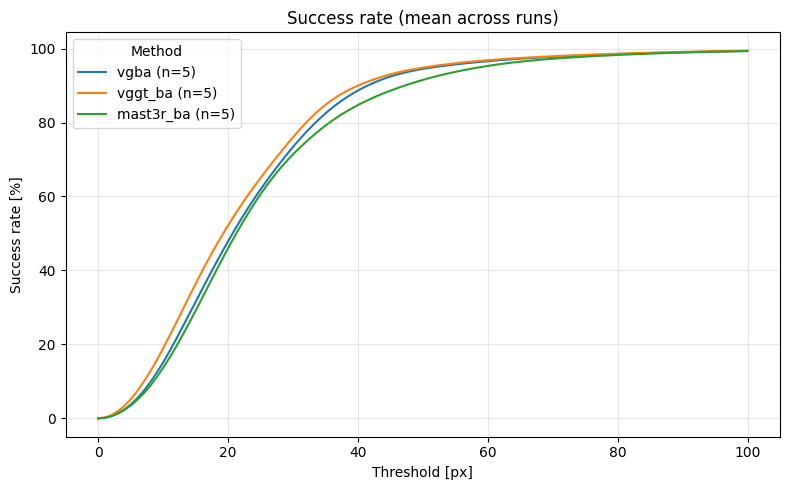

Saved averaged CSV: hand_triangulation_output\aggregate\success_rate_curves_mean_across_runs.csv
Saved plot:         hand_triangulation_output\aggregate\success_rate_curves_mean_across_runs_new.pdf


In [13]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- config ---
methods = ["vgba", "vggt_ba", "mast3r_ba"]
runs    = ["run0", "run1", "run2", "run3", "run4"]
base_dir = Path("hand_triangulation_output")
out_dir  = base_dir / "aggregate"               # where to save the averaged outputs
NUM_THRESH = 100                                # common grid resolution
# -------------

os.makedirs(out_dir, exist_ok=True)

# Load curves from each run
per_run_curves = {}  # {run: DataFrame(threshold_px + each method)}
for run in runs:
    csv_path = base_dir / run / "success_rate_curves_combined.csv"
    if not csv_path.exists():
        print(f"[WARN] Missing file for {run}: {csv_path}")
        continue
    df = pd.read_csv(csv_path)
    needed = {"threshold_px", *methods}
    if not needed.issubset(df.columns):
        print(f"[WARN] {csv_path} doesn't have required columns {needed}. Skipping.")
        continue

    # clean & sort
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["threshold_px"])
    df = df.sort_values("threshold_px")
    df = df[df["threshold_px"] >= 0]
    if df.empty:
        print(f"[WARN] Empty/invalid thresholds in {csv_path}. Skipping.")
        continue

    per_run_curves[run] = df[["threshold_px", *methods]].reset_index(drop=True)

if not per_run_curves:
    raise RuntimeError("No valid run CSVs found.")

# Build a common threshold grid: from 0 to the smallest maximum threshold across runs
tmax_per_run = []
for df in per_run_curves.values():
    tmax_per_run.append(float(df["threshold_px"].to_numpy()[-1]))
t_max_common = float(min(tmax_per_run))
thresholds = np.linspace(0.0, t_max_common, NUM_THRESH)

# Interpolate each run onto the common grid
interp_by_run = {}  # {run: {method: y_on_common_grid}}
for run, df in per_run_curves.items():
    t = df["threshold_px"].to_numpy()
    # ensure strictly increasing thresholds for interp
    keep = np.concatenate(([True], np.diff(t) > 0))
    t = t[keep]
    interp_by_run[run] = {}
    for m in methods:
        y = df[m].to_numpy()[keep]
        interp_by_run[run][m] = np.interp(thresholds, t, y)

# Stack runs and compute mean (ignore methods with no data in a run by skipping that run)
mean_curves = {}
n_used = {m: 0 for m in methods}
for m in methods:
    ys = []
    for run in interp_by_run:
        if m in interp_by_run[run]:
            ys.append(interp_by_run[run][m])
    if ys:
        ys = np.vstack(ys)
        mean_curves[m] = ys.mean(axis=0)
        n_used[m] = ys.shape[0]

if not mean_curves:
    raise RuntimeError("No method data available after interpolation.")

# Save averaged CSV
avg_df = pd.DataFrame({"threshold_px": thresholds})
for m in methods:
    if m in mean_curves:
        avg_df[m] = mean_curves[m]
avg_csv_path = out_dir / "success_rate_curves_mean_across_runs.csv"
avg_df.to_csv(avg_csv_path, index=False)

# Plot: one mean curve per method
plt.figure(figsize=(8, 5))
for m in methods:
    if m in mean_curves:
        plt.plot(thresholds, mean_curves[m]*100, label=f"{m} (n={n_used[m]})")
plt.xlabel("Threshold [px]")
plt.ylabel("Success rate [%]")
plt.title("Success rate (mean across runs)")
plt.grid(True, which="both", axis="both", alpha=0.3)
plt.legend(title="Method")
plt.tight_layout()
plot_path = out_dir / "success_rate_curves_mean_across_runs_new.pdf"
plt.savefig(plot_path)
plt.show()

print(f"Saved averaged CSV: {avg_csv_path}")
print(f"Saved plot:         {plot_path}")


# Ransac

In [ ]:
import os
import json
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import cv2
from scipy.optimize import least_squares
from tqdm import tqdm


# ----------------------------- Config ---------------------------------
cams_folder = "5 cameras"
pixel_th = "40 pixel"
runs_to_cameras: Dict[str, List[str]] = {
    "run0": ['gopro5', 'gopro6', 'gopro7', 'gopro8', 'gopro9'],
    "run1": ['gopro6', 'gopro7', 'gopro8', 'gopro10', 'gopro12'],
    "run2": ['gopro5', 'gopro7', 'gopro9', 'gopro10', 'gopro12'],
    "run3": ['gopro5', 'gopro6', 'gopro8', 'gopro9', 'gopro12'],
    "run4": ['gopro5', 'gopro6', 'gopro9', 'gopro10', 'gopro12'],
}
methods = ["vgba","vggt_ba","mast3r_ba","mgba"]

pose_outputs_dir = Path("pose_outputs/cha/synced_cut_long")
intrinsics_dir   = Path("camera_poses/cha/camera_intrinsics")

output_root = Path(f"hand_triangulation_output/{cams_folder}/{pixel_th}")
output_root.mkdir(parents=True, exist_ok=True)

# RANSAC params
RANSAC_THRESH_PX = 40.0
RANSAC_MAX_ITERS = 200
MIN_INLIERS = 2
SCORE_THRESH = 0.3

HAND_JOINTS = 21
HAND_KEYS = ["left_hand_instances", "right_hand_instances"]  # order preserved in outputs
# ----------------------------------------------------------------------


# ============================= I/O HELPERS =============================

def load_intrinsics_for_camera(intrinsics_dir: Path, cam: str) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load intrinsics and distortion for a camera.
    Expects files named like '{cam}_synced_intrinsics.json' in intrinsics_dir.
    Returns (K, dist) where K is 3x3, dist is (k1,k2,p1,p2,k3) as 1x5.
    """
    candidates = [
        intrinsics_dir / f"{cam}_synced_intrinsics.json",
    ]
    for fp in candidates:
        if fp.exists():
            with open(fp, "r") as f:
                intr = json.load(f)
            # Expected structure (OpenCV style in your provided file)
            k = np.array(intr["sensors"]["RGB"]["intrinsics"]["data"], dtype=float).reshape(3, 3)
            dist = np.array(intr["sensors"]["RGB"]["distortionCoefficients"]["data"], dtype=float).reshape(-1)
            return k, dist
    raise FileNotFoundError(f"Intrinsics for {cam} not found. Tried: {candidates}")


def _euler_ZYX_to_R(euler_deg: List[float]) -> np.ndarray:
    """
    ZYX (yaw, pitch, roll) in DEGREES -> rotation matrix.
    Convention: R = Rz * Ry * Rx
    """
    z, y, x = np.deg2rad(euler_deg)
    cz, sz = np.cos(z), np.sin(z)
    cy, sy = np.cos(y), np.sin(y)
    cx, sx = np.cos(x), np.sin(x)

    Rz = np.array([[ cz, -sz, 0.0],
                   [ sz,  cz, 0.0],
                   [0.0, 0.0, 1.0]])
    Ry = np.array([[ cy, 0.0,  sy],
                   [0.0, 1.0, 0.0],
                   [-sy, 0.0,  cy]])
    Rx = np.array([[1.0, 0.0,  0.0],
                   [0.0,  cx, -sx],
                   [0.0,  sx,  cx]])
    return Rz @ Ry @ Rx


def load_extrinsics_only_ZYX_t(extr_path: Path, cams_order: List[str]) -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
    """
    STRICT loader for extrinsics in this exact per-camera format:

    "gopro12": {
        "euler_ZYX": [degZ, degY, degX],
        "t": [-1.641, 2.016, -1.085]
    }

    These are **camera poses** (camera->world). We convert to world->camera:
    R_wc = R_cw.T
    t_wc = -R_wc @ t_cw

    Returns: {cam: (R_wc, t_wc)}
    """
    with open(extr_path, "r") as f:
        data = json.load(f)

    # Validate format & collect
    out: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}
    for cam in cams_order:
        block = data.get(cam)
        if not isinstance(block, dict) or "euler_ZYX" not in block or "t" not in block:
            raise ValueError(
                f"Extrinsics file must contain per-camera blocks with 'euler_ZYX' and 't'. "
                f"Missing or invalid for '{cam}'."
            )
        R_cw = _euler_ZYX_to_R(block["euler_ZYX"])
        t_cw = np.array(block["t"], dtype=float).reshape(3,)
        R_wc = R_cw.T
        t_wc = -R_wc @ t_cw
        out[cam] = (R_wc, t_wc)

    return out


def load_pose_json(path: Path) -> Dict:
    with open(path, "r") as f:
        return json.load(f)


def frames_to_maps(instances: List[Dict]) -> Dict[int, Dict]:
    """
    Convert list of frames [{'frame_id': int, 'instances':[...]}] to map
    frame_id -> instance dict (first instance only).
    If no instances present in a given frame entry, this maps to None.
    """
    out = {}
    for item in instances:
        fid = int(item.get("frame_id", -1))
        insts = item.get("instances", [])
        out[fid] = insts[0] if (isinstance(insts, list) and len(insts) > 0) else None
    return out


def gather_camera_streams(pose_outputs_dir: Path, cams_order: List[str], hand_keys: List[str]) -> Dict[str, Dict[str, Dict[int, Dict]]]:
    """
    Returns:
    cams[cam_name][hand_key][frame_id] -> instance dict with 'keypoints' (21x2) and 'keypoint_scores'(21)
    Only includes cameras with available files.
    """
    cams = {}
    for cam in cams_order:
        pose_file = pose_outputs_dir / f"{cam}_synced_cut_wholebody.json"
        if not pose_file.exists():
            # allow loose match if filename differs a bit
            alts = list(pose_outputs_dir.glob(f"{cam}*wholebody*.json"))
            if alts:
                pose_file = alts[0]
        if not pose_file.exists():
            print(f"[WARN] Missing 2D detections for {cam}, skipping.")
            continue

        d = load_pose_json(pose_file)
        cam_dict = {}
        for hand_key in hand_keys:
            if hand_key not in d:
                print(f"[WARN] {hand_key} not found in {pose_file.name}, skipping this hand.")
                continue
            cam_dict[hand_key] = frames_to_maps(d[hand_key])
        cams[cam] = cam_dict
    return cams


# ============================= GEOMETRY ================================

def undistort_points_to_pixel(uvs: np.ndarray, K: np.ndarray, dist: np.ndarray) -> np.ndarray:
    """
    Undistort pixel coordinates using OpenCV and return UNDISTORTED pixel coords (not normalized).
    cv2.undistortPoints with P=K returns pixel coordinates consistent with K.
    """
    if uvs.size == 0:
        return uvs
    pts = uvs.reshape(-1, 1, 2).astype(np.float32)
    undist = cv2.undistortPoints(pts, K, dist, P=K)  # -> (N,1,2) pixel coords
    return undist.reshape(-1, 2).astype(np.float64)


def build_projection_matrix(K: np.ndarray, R: np.ndarray, t: np.ndarray) -> np.ndarray:
    """P = K [R | t]  with world->camera: x_cam = R X + t"""
    Rt = np.hstack([R, t.reshape(3, 1)])
    return K @ Rt


def dlt_triangulate_multi(P_list: List[np.ndarray], xy_list: List[np.ndarray]) -> np.ndarray:
    """
    Linear n-view triangulation using DLT on UNDISTORTED pixel points.
    Returns 3D point (x,y,z) in world coords. NaNs if <2 views or ill-conditioned.
    """
    if len(P_list) < 2:
        return np.array([np.nan, np.nan, np.nan], dtype=float)

    A = []
    for P, (u, v) in zip(P_list, xy_list):
        A.append(u * P[2, :] - P[0, :])
        A.append(v * P[2, :] - P[1, :])
    A = np.asarray(A)

    try:
        _, _, Vt = np.linalg.svd(A)
        X = Vt[-1]
        if abs(X[3]) < 1e-9:
            return np.array([np.nan, np.nan, np.nan], dtype=float)
        X = X[:3] / X[3]
        return X
    except np.linalg.LinAlgError:
        return np.array([np.nan, np.nan, np.nan], dtype=float)


def refine_triangulation(X_init: np.ndarray, P_list: List[np.ndarray], xy_list: List[np.ndarray]) -> np.ndarray:
    """
    Non-linear refinement of 3D point using Levenberg-Marquardt to minimize reprojection error.
    Runs only on the provided inlier set (P_list, xy_list).
    """
    if np.any(~np.isfinite(X_init)):
        return X_init
    
    def residuals(X):
        """Compute reprojection residuals for all views"""
        errs = []
        for P, xy_obs in zip(P_list, xy_list):
            # Project 3D point
            Xh = np.hstack([X, 1.0])
            x_proj = P @ Xh
            if abs(x_proj[2]) < 1e-9:
                errs.extend([1e6, 1e6])  # large penalty for invalid projection
            else:
                xy_proj = x_proj[:2] / x_proj[2]
                errs.extend(xy_proj - xy_obs)
        return np.array(errs)
    
    try:
        result = least_squares(
            residuals,
            X_init,
            method='lm',  # Levenberg-Marququardt
            ftol=1e-6,
            xtol=1e-6,
            max_nfev=100
        )
        if result.success:
            return result.x
        else:
            return X_init
    except Exception:
        return X_init


def project(P: np.ndarray, X: np.ndarray) -> np.ndarray:
    """Project 3D point with P (3x4) -> pixel (u,v)."""
    Xh = np.hstack([X, 1.0])
    x = P @ Xh
    if abs(x[2]) < 1e-9:
        return np.array([np.nan, np.nan], dtype=float)
    return (x[:2] / x[2]).astype(float)


def ransac_triangulate(P_list: List[np.ndarray],
                       xy_list: List[np.ndarray],
                       thresh_px: float = RANSAC_THRESH_PX,
                       max_iters: int = RANSAC_MAX_ITERS,
                       min_inliers: int = MIN_INLIERS,
                       rng: np.random.Generator = None):
    """
    RANSAC over view pairs. Returns (best_inlier_mask, X_best).
    If no model found with >= min_inliers, returns (None, [nan,nan,nan]).
    """
    n = len(P_list)
    if n < 2:
        return None, np.array([np.nan, np.nan, np.nan], dtype=float)
    if rng is None:
        rng = np.random.default_rng()

    best_inliers = None
    best_count = 0
    best_sum_err = np.inf
    X_best = np.array([np.nan, np.nan, np.nan], dtype=float)

    idxs = np.arange(n)

    # Try all pairs if small N, otherwise sample
    all_pairs = [(i, j) for i in range(n) for j in range(i+1, n)]
    iters = min(max_iters, len(all_pairs)) if len(all_pairs) > 0 else max_iters
    pairs_to_try = all_pairs
    if len(all_pairs) > max_iters:
        pairs_to_try = [tuple(rng.choice(n, size=2, replace=False)) for _ in range(max_iters)]

    for (i, j) in pairs_to_try[:iters]:
        Pi, Pj = P_list[i], P_list[j]
        xyi, xyj = xy_list[i], xy_list[j]
        X_candidate = dlt_triangulate_multi([Pi, Pj], [xyi, xyj])
        if not np.isfinite(X_candidate).all():
            continue

        # Evaluate all views
        errs = []
        for P, xy in zip(P_list, xy_list):
            pr = project(P, X_candidate)
            if np.any(~np.isfinite(pr)):
                errs.append(np.inf)
            else:
                errs.append(np.linalg.norm(pr - xy))
        errs = np.asarray(errs)

        inlier_mask = errs < thresh_px
        count = int(inlier_mask.sum())
        sum_err = float(np.nan_to_num(errs[inlier_mask]).sum()) if count >= 1 else np.inf

        if count > best_count or (count == best_count and sum_err < best_sum_err):
            best_count = count
            best_sum_err = sum_err
            best_inliers = inlier_mask.copy()
            X_best = X_candidate.copy()

    if best_inliers is None or best_count < min_inliers:
        return None, np.array([np.nan, np.nan, np.nan], dtype=float)

    # Recompute from all inliers for a better initial estimate
    P_in = [P for P, m in zip(P_list, best_inliers) if m]
    xy_in = [xy for xy, m in zip(xy_list, best_inliers) if m]
    X_init = dlt_triangulate_multi(P_in, xy_in)
    return best_inliers, X_init


# ============================== MAIN ==================================
for run, cam_list in runs_to_cameras.items():
    print(f"\n=== Processing {run}: cameras={cam_list} ===")
    for method in methods:
        # extrinsics path: .../{method}/poses_spp_surgeon_no_occlusion_run_X.json
        extrinsics_path = Path(f"camera_poses/cha/camera_extrinsics/{cams_folder}/{method}/poses_spp_surgeon_no_occlusion_{run.replace('run','run_')}.json")
        if not extrinsics_path.exists():
            print(f"[WARN] Missing extrinsics for {method} {run}: {extrinsics_path}")
            continue

        # Load extrinsics
        try:
            extr = load_extrinsics_only_ZYX_t(extrinsics_path, cam_list)
        except Exception as e:
            print(f"[WARN] Bad extrinsics for {method} {run}: {e}")
            continue

        # Load intrinsics for all cams; warn if missing
        intr: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}
        for cam in cam_list:
            try:
                intr[cam] = load_intrinsics_for_camera(intrinsics_dir, cam)
            except FileNotFoundError as e:
                print(f"[WARN] {e}")

        # Load 2D streams
        cams = gather_camera_streams(pose_outputs_dir, cam_list, HAND_KEYS)
        available_cams = [c for c in cam_list if c in cams and c in intr and c in extr]
        if len(available_cams) < 2:
            print(f"[WARN] Need at least two cameras with 2D+K+extr for {method} {run}. Have: {available_cams}")
            continue

        # Frame range: union of frame_ids across available cams for the hands
        all_frame_ids = set()
        for cam in available_cams:
            for hand_key in HAND_KEYS:
                if hand_key in cams[cam]:
                    all_frame_ids.update(cams[cam][hand_key].keys())
        if not all_frame_ids:
            print(f"[WARN] No frames in 2D files for {method} {run}.")
            continue
        max_frame_id = max(all_frame_ids)
        num_frames = max_frame_id + 1

        # Prepare outputs
        hand_3d = [np.full((num_frames, HAND_JOINTS, 3), np.nan, dtype=float) for _ in HAND_KEYS]
        repro_err_px = [
            {cam: np.full((num_frames, HAND_JOINTS), np.nan, dtype=float) for cam in available_cams}
            for _ in HAND_KEYS
        ]
        refinement_errors_all = []

        # Projection matrices
        P_mats = {}
        for cam in available_cams:
            K, _ = intr[cam]
            R, t = extr[cam]  # world->camera
            P_mats[cam] = build_projection_matrix(K, R, t)

        # Triangulate with RANSAC + refinement
        rng = np.random.default_rng(42)
        for fid in tqdm(range(num_frames), desc=f"[{method}:{run}] RANSAC+refine"):
            for h_idx, hand_key in enumerate(HAND_KEYS):
                # Gather observations per joint
                per_joint_obs = {j: [] for j in range(HAND_JOINTS)}
                for cam in available_cams:
                    fmap = cams[cam].get(hand_key, {})
                    inst = fmap.get(fid, None)
                    if not inst: continue
                    kps = np.asarray(inst.get("keypoints", []), dtype=float)          # (21,2)
                    scs = np.asarray(inst.get("keypoint_scores", []), dtype=float)    # (21,)
                    if kps.shape[0] != HAND_JOINTS or scs.shape[0] != HAND_JOINTS: continue
                    K, dist = intr[cam]
                    undist_pixels = undistort_points_to_pixel(kps, K, dist)           # (21,2)
                    for j in range(HAND_JOINTS):
                        if scs[j] > SCORE_THRESH and np.isfinite(undist_pixels[j]).all():
                            per_joint_obs[j].append((cam, P_mats[cam], undist_pixels[j], scs[j]))

                # Triangulate each joint
                for j in range(HAND_JOINTS):
                    obs = per_joint_obs[j]
                    if len(obs) < 2: continue
                    obs.sort(key=lambda x: x[3], reverse=True)  # by score
                    cams_j   = [o[0] for o in obs]
                    P_list   = [o[1] for o in obs]
                    xy_list  = [o[2] for o in obs]

                    # RANSAC
                    inlier_mask, X_init = ransac_triangulate(P_list, xy_list,
                                                             thresh_px=RANSAC_THRESH_PX,
                                                             max_iters=RANSAC_MAX_ITERS,
                                                             min_inliers=MIN_INLIERS,
                                                             rng=rng)
                    if inlier_mask is None: continue

                    # Inliers only
                    P_in  = [P for P, m in zip(P_list, inlier_mask) if m]
                    xy_in = [xy for xy, m in zip(xy_list, inlier_mask) if m]
                    cam_in_idx = [idx for idx, m in enumerate(inlier_mask) if m]

                    # LM refinement on inliers
                    X_ref = refine_triangulation(X_init, P_in, xy_in)
                    hand_3d[h_idx][fid, j, :] = X_ref

                    # Reprojection errors for inlier cams
                    for local_idx, P in enumerate(P_in):
                        global_obs_idx = cam_in_idx[local_idx]
                        cam_name = cams_j[global_obs_idx]
                        proj = project(P, X_ref)
                        err = np.linalg.norm(proj - xy_in[local_idx]) if np.all(np.isfinite(proj)) else np.nan
                        repro_err_px[h_idx][cam_name][fid, j] = float(err)
                        if np.isfinite(err):
                            refinement_errors_all.append(err)

        # Save outputs
        save_dir = output_root / method / run
        save_dir.mkdir(parents=True, exist_ok=True)

        np.savez_compressed(
            save_dir / "hands_3d_and_reproj_errors.npz",
            left_hand_3d=hand_3d[0],
            right_hand_3d=hand_3d[1],
            left_errors={cam: arr for cam, arr in repro_err_px[0].items()},
            right_errors={cam: arr for cam, arr in repro_err_px[1].items()},
            cameras=np.array(available_cams, dtype=object),
            score_threshold=SCORE_THRESH,
            ransac_threshold_px=RANSAC_THRESH_PX,
        )

        # CSV (only inlier-camera errors are filled; others are NaN)
        csv_path = save_dir / "reprojection_errors.csv"
        with open(csv_path, "w", newline="") as f:
            f.write("hand,frame,joint,camera,error_px\n")
            for h_idx, hand_key in enumerate(HAND_KEYS):
                for cam in available_cams:
                    err = repro_err_px[h_idx][cam]
                    rows = np.argwhere(~np.isnan(err))
                    for r in rows:
                        fr, jnt = int(r[0]), int(r[1])
                        f.write(f"{hand_key},{fr},{jnt},{cam},{err[fr, jnt]:.6f}\n")

        # Report average reprojection error after refinement (inliers)
        if refinement_errors_all:
            mean_err = float(np.mean(refinement_errors_all))
            print(f"[{method} | {run}] Mean reprojection error after refinement (inliers): {mean_err:.3f} px")
        else:
            print(f"[{method} | {run}] No inlier reprojection errors to average.")

        print(f"- Saved NPZ: {save_dir / 'hands_3d_and_reproj_errors.npz'}")
        print(f"- Saved CSV: {csv_path}")


In [34]:
from pathlib import Path
import pandas as pd
import numpy as np

# --- config ---
pixel_th = "10 pixel"
methods = ["vgba", "vggt_ba", "mast3r_ba","mgba"]
runs    = ["run0", "run1", "run2", "run3", "run4"]
base_dir = Path(f"hand_triangulation_output/{cams_folder}/{pixel_th}")
out_dir = base_dir / "aggregate"
out_dir.mkdir(parents=True, exist_ok=True)
# -------------


rows = []
# also keep raw errors per method for a pooled (weighted) mean
pooled_errors_by_method = {m: [] for m in methods}

for method in methods:
    for run in runs:
        csv_path = base_dir / method / run / "reprojection_errors.csv"
        if not csv_path.exists():
            print(f"[WARN] Missing CSV: {csv_path}")
            continue

        df = pd.read_csv(csv_path)
        if "error_px" not in df.columns:
            print(f"[WARN] No 'error_px' in {csv_path}")
            continue

        errs = df["error_px"].replace([np.inf, -np.inf], np.nan).dropna().values
        if errs.size == 0:
            print(f"[WARN] No finite inlier errors in {csv_path}")
            continue

        rows.append({
            "method": method,
            "run": run,
            "num_inlier_obs": errs.size,
            "mean_refined_reproj_err_px": float(np.mean(errs))
        })
        pooled_errors_by_method[method].append(errs)

# Build per-run table
if not rows:
    raise RuntimeError("No results found. Did you run the triangulation script first?")

per_run_df = pd.DataFrame(rows).sort_values(["method", "run"]).reset_index(drop=True)
per_run_csv = out_dir / "mean_refined_reproj_error_by_method_run.csv"
per_run_df.to_csv(per_run_csv, index=False)

# Build per-method pooled means (weighted by number of observations)
method_rows = []
for m in methods:
    if pooled_errors_by_method[m]:
        all_errs = np.concatenate(pooled_errors_by_method[m], axis=0)
        method_rows.append({
            "method": m,
            "num_inlier_obs": int(all_errs.size),
            "mean_refined_reproj_err_px": float(np.mean(all_errs))
        })

per_method_df = pd.DataFrame(method_rows).sort_values("method").reset_index(drop=True)
per_method_csv = out_dir / "mean_refined_reproj_error_by_method.csv"
per_method_df.to_csv(per_method_csv, index=False)

# Print both
print("\nMean reprojection error after refinement (inliers) — per method × run:")
print(per_run_df.to_string(index=False))

print("\nMean reprojection error after refinement (inliers) — pooled per method:")
print(per_method_df.to_string(index=False))

print(f"\nSaved per-run CSV   → {per_run_csv}")
print(f"Saved per-method CSV→ {per_method_csv}")



Mean reprojection error after refinement (inliers) — per method × run:
   method  run  num_inlier_obs  mean_refined_reproj_err_px
mast3r_ba run0          122971                    3.561053
mast3r_ba run1          134024                    3.737480
mast3r_ba run2          108308                    3.425312
mast3r_ba run3          108536                    3.014361
mast3r_ba run4           98954                    2.905919
     mgba run0          122519                    3.664308
     mgba run1          124964                    3.545461
     mgba run2          140658                    4.045685
     mgba run3          119396                    3.190584
     mgba run4          114575                    2.614208
     vgba run0          119477                    3.514963
     vgba run1          104422                    1.960766
     vgba run2          110151                    2.637455
     vgba run3          109656                    2.793782
     vgba run4          124636             